# Autonomous activated amplification - Simulations

## Initialisation of libraries and parameters

In [1]:
import matplotlib.pyplot as plt
from Functions import *
from Hamiltonians import *
from FigOMerit_functions import *
from scipy.stats.qmc import *
import os

# Enable LaTeX rendering for text
plt.rcParams.update({
    "text.usetex": True,         # Use LaTeX for text rendering
    "font.family": "serif",      # Use a serif font
    "font.serif": ["Computer Modern"],  # Use Computer Modern for a classic LaTeX look
    "axes.titlesize": 14,        # Title font size
    "axes.labelsize": 12,        # Label font size
    "xtick.labelsize": 10,       # X-tick font size
    "ytick.labelsize": 10,       # Y-tick font size
})


def chop(expr, *, max=10**(-10)):
    return [i if i > max else 0 for i in expr]


In [2]:
#######################################################################
### Variables Most relevant for below (the ones that we investigate)###
#######################################################################

parameters = {
    # General parameters
    "d_l": 3,         # Ladder dimension
    "e_max": 5,       # Energy of most excited level of ladder (threshold energy)
    "e_s": 0.1,       # System (photon) energy
    "TH": 10,         # Hot bath temperature
    "TC": 0.1,        # Cold bath temperature

    # Interaction strengths
    "g_sl": 1,        # System-ladder interaction strength
    "g_ml": 1,        # Machine-ladder interaction strength

    # Energies
    "e_C": 1,       # Cold bath gap
    "e_C_factor": 0.3, # Factor for cold bath gap calculation
    "t_f": 3000,       # Final time
    "t_steps": 3000,   # Number of timesteps

    # Jump rates
    "rateM": 1,       # Dissipator rate machine-baths
    "rateD": 1,       # Dissipation rate detection channel
    "rateB": 0.8,     # Thermalizing rate ladder-bath
    "Tb": 0.1,        # Ladder bath temperature
    "Td": 0.1,        # Detection channel temperature

    # Constant k
    "k": 1
}
parameters["e_l"]=(parameters["e_max"]-parameters["e_s"])/(parameters["d_l"]-2)
parameters["e_C"]=parameters["e_l"]*parameters["e_C_factor"]
parameters["e_l"]=(-parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2)
parameters["TV"]=TV_from_TH_TC(parameters["TH"],parameters["TC"],parameters["e_C"],parameters["e_l"])

# Assigning dictionary values to variables
d_l = parameters["d_l"]
e_max = parameters["e_max"]
e_s = parameters["e_s"]
TH = parameters["TH"]
TC = parameters["TC"]
rateB = parameters["rateB"]

g_sl = parameters["g_sl"]
g_ml = parameters["g_ml"]

e_C = parameters["e_C"]
e_C_factor = parameters["e_C_factor"]
t_f = parameters["t_f"]
t_steps = parameters["t_steps"]

rateM = parameters["rateM"]
rateD = parameters["rateD"]
Tb = parameters["TC"]
Td = parameters["TC"]

k = parameters["k"]


# Dynamics visualised

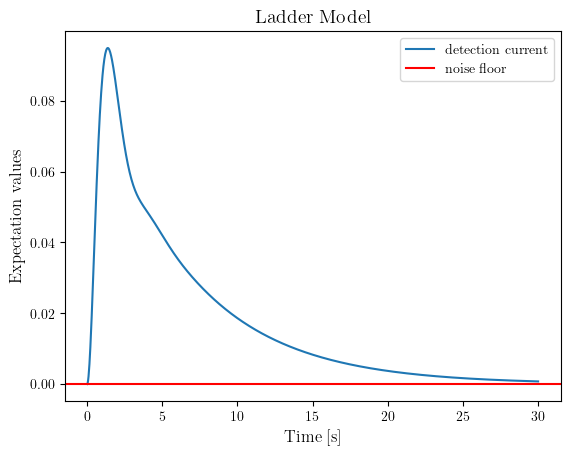

In [100]:
parameters["t_f"]=30
parameters["t_steps"]=1000
parameters["TC"]=0.01
parameters["Tb"]=parameters["TC"]
parameters["Td"]=parameters["TC"]
parameters["TH"]=1000
times=np.linspace(0,parameters["t_f"],parameters["t_steps"])
dynamics=get_dynamics_k_new(parameters)
result=dynamics[0]
steady_prev_run=dynamics[1]

fig, ax = plt.subplots()
plt.plot(times,result.expect[0],label="detection current")

e_ops=dynamics[2]

ax.set_xlabel('Time [s]')
ax.set_ylabel('Expectation values')
ax.legend(("detection current", "ready state","Machine entropy production", "Machine heat draw"))
plt.title("Ladder Model")

noise_floor_curr=expect(e_ops[0],steady_prev_run)
plt.axhline(y=noise_floor_curr,color="red",label="noise floor")
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/transient_dyn_1.eps', format='eps')

# Figures of Merit plots

## Optimisation

In this part I try to optimize e.g. the efficiency over a range of parameters to see if there is a fundamental trade-off relation

In [ ]:
from scipy.optimize import minimize
import numpy as np


def objective(params, parameters):
        TC, TV, g_ml, rateD = params
        parameters.update({"TC": TC, "TV": TV, "g_ml": g_ml, "rateD": rateD})

        # Set additional parameters
        parameters["Tb"] = parameters["TC"]
        parameters["Td"] = parameters["TC"]

        # Compute TH
        parameters["TH"] = TH_from_TV_TC(
            parameters["TV"], parameters["TC"],
            parameters["e_l"] * parameters["e_C_factor"],
            parameters["e_l"]
        )

        # Hamiltonian
        H = (
            H0_k(parameters["e_s"], parameters["e_l"], parameters["e_C"],
                parameters["d_l"], parameters["k"])
            + HI_k(parameters["g_sl"], parameters["g_ml"],
                parameters["d_l"], parameters["k"])
        )

        # Jump operators and Liouvillian
        e_ops = get_e_ops(parameters)
        c_ops = c_ops_k(
            parameters["rateM"], parameters["rateB"], parameters["rateD"], parameters["TH"],
            parameters["TC"], parameters["Tb"], parameters["Td"], parameters["e_s"],
            parameters["e_C"], parameters["e_l"], parameters["d_l"], parameters["k"]
        )

        l = liouvillian(H, c_ops)
        drinv = pseudo_inverse(l, method="spsolve")
        steady = steadystate(H, c_ops)

        # Initial state for efficiency calculation
        init = operator_to_vector(tensor(
            ptrace(steady, [0, 1, 2]),
            matrix_element(1, 1, 2)
        ))

        # Compute efficiency
        efficiency = L_efficiency(drinv, init, e_ops, parameters)

        # print(f"Params: {parameters} | Efficiency: {efficiency}")

        return -efficiency  # We minimize, so return negative efficiency
def constraint_TH(params, parameters):
        """ Ensures TH >= constraint_value """
        TC, TV, _, _ = params
        TH = TH_from_TV_TC(
            TV, TC,
            parameters["e_l"] * parameters["e_C_factor"],
            parameters["e_l"]
        )
        constraint_value = TC * (parameters["e_l"] + parameters["e_C"]) / (parameters["e_l"] * parameters["e_C_factor"])
        return TH - constraint_value  # Must be >= 0
def constraint_dark_count(params, parameters):
    """ Ensures dark_count = target_dark_count_rate """
    TC, TV, g_ml, rateD = params
    parameters.update({"TC": TC, "TV": TV, "g_ml": g_ml, "rateD": rateD})

    # Set additional parameters
    parameters["Tb"] = parameters["TC"]
    parameters["Td"] = parameters["TC"]

    # Compute TH
    parameters["TH"] = TH_from_TV_TC(
        parameters["TV"], parameters["TC"],
        parameters["e_l"] * parameters["e_C_factor"],
        parameters["e_l"]
    )

    # Hamiltonian
    H = (
        H0_k(parameters["e_s"], parameters["e_l"], parameters["e_C"],
            parameters["d_l"], parameters["k"])
        + HI_k(parameters["g_sl"], parameters["g_ml"],
            parameters["d_l"], parameters["k"])
    )

    # Jump operators and Liouvillian
    e_ops = get_e_ops(parameters)
    c_ops = c_ops_k(
        parameters["rateM"], parameters["rateB"], parameters["rateD"], parameters["TH"],
        parameters["TC"], parameters["Tb"], parameters["Td"], parameters["e_s"],
        parameters["e_C"], parameters["e_l"], parameters["d_l"], parameters["k"]
    )


    drinv = 0
    steady = steadystate(H, c_ops)

    # Compute dark count
    dark_count = L_dark_counts(drinv, steady, e_ops, parameters)

    return target_dark_count_rate - dark_count  # Must be = 0


target_dark_count_rate_list=np.linspace(8*10**(-9),10**(-8),10)

optimal_params_list=[]
optimal_efficiency_list=[]

for target_dark_count_rate in target_dark_count_rate_list:
    # Define bounds for each parameter
    bounds = [
        (0.1, 1),   # TC
        (-10, -0.05), # TV
        (0.1, 1),   # g_ml
        (0.1, 10)    # rateD
    ]

    # Objective function (maximize efficiency)


    # **Constraint functions (must be >= 0 to be satisfied)**

    # Define constraints
    constraints = [
        {"type": "ineq", "fun": constraint_TH, "args": (parameters,)},   # TH constraint
        {"type": "eq", "fun": constraint_dark_count, "args": (parameters,)}  # Dark count constraint
    ]

    # Initial guess for parameters
    x0 = [0.5, -5, 0.5, 0.5]  # Choose reasonable initial values

    # Run optimization
    result = minimize(objective, x0, args=(parameters,), bounds=bounds, constraints=constraints, method="SLSQP")

    # Extract optimal parameters
    optimal_params = result.x
    optimal_efficiency = -result.fun  # Convert back from minimization

    optimal_params_list.append(optimal_params)
    optimal_efficiency_list.append(optimal_efficiency)

    # print("Optimal Parameters:", optimal_params)
    # print("Optimal Efficiency:", optimal_efficiency)


## Random sampling data sets


Sampling from uniform distributions first, and later maybe from Latin Hypercube sampling

Parameters that are random sampled and parameter range

$d\in [3,40]$

$R_B\in [0.01,2]$

$T_H \in [0.01, 10]$

$T_C \in [0.01,10]$ with the constraint that $\frac{E_C}{E_H}T_H\geq T_C$ to stay in the heat engine regime

$E_{max} \in [0.1,10]$ (will be fixed for now at $5$)

$E_f \in [0.01,1]$ (will be fixed for now at $0.1$)



### Generating Latin Hypercube random sample data sets

In [92]:
import warnings
import pandas as pd
#Sampling ranges

rateD_range=[0.0,1]
g_ml_range=[0.0,1]
T_C_range=[0.01,1]
T_V_range=[-10,-0.001]

####!!!! These are only valid for efficiency and dark count rate, as we dont need the transient for them !!!!#########
parameters["t_f"]=1
parameters["t_steps"]=10
########################################################################################################################

filename="FOM_Dinv_exact_v3"

parameters["k"]=1
n=0
errors=0

while n < 50:
    try:


        # Generate sample set
        sample_set = np.array(generate_sample_set_TC_TV_g_ml_rateD(
            T_C_range, T_V_range, g_ml_range, rateD_range,parameters, 50))

        # Generate dataset
        dset = generate_dataset_TC_TV_g_ml_rateD(sample_set, filename, parameters)

        print(f"Sample set no. {n}, dataset size {np.array(dset).shape}", end="\r", flush=True)
        n += 1  # Increment only on success

    except ValueError as e:
        errors += 1
        print(f"ValueError encountered: {e}. ..................(total errors: {errors})", end="\r", flush=True)
    if errors > 100:
        break
if errors > 0:
    print(f"Completed with {errors} errors during execution.")
else:
    print("Execution completed without errors.")

RuntimeError: failed to factorize matrix at line 441 in file ../scipy/sparse/linalg/_dsolve/SuperLU/SRC/zpanel_bmod.c


### Scatter plots

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


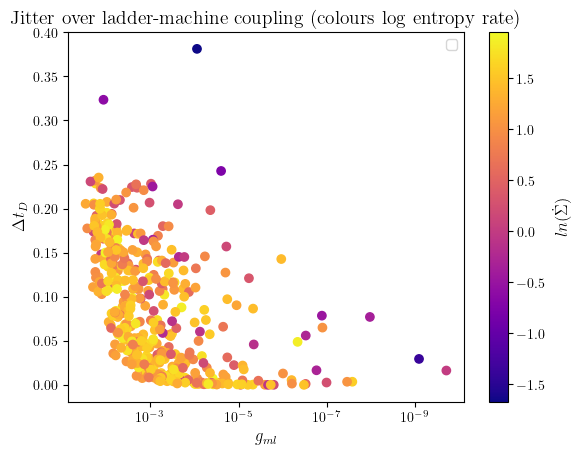

In [106]:


dset= pd.read_csv("FOM_Dinv_exact_v3")
condition = dset["k"] == 1
# condition &= dset["efficiency"] >0
# condition &= dset["efficiency"] <1
# condition &= dset["rateD"] >15
condition &= dset["rateD"] <0.8
# condition &= dset["g_ml"] >10
# condition &= dset["g_ml"] <12

# condition &= dset["TC"] >0.6
# condition &= dset["TC"] <0.8
# condition &= dset["TV"] <-3
# condition &= dset["TV"] >-4
# condition &= dset["TH"] >dset["TC"]*(dset["e_l"]+dset["e_C"])/dset["e_C"]

# condition &= dset["TV"] < -5
# condition &= dset["g_ml"] <1

# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000

dset=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$g_{ml}$")
ax.set_ylabel("$\Delta t_D$")

plt.gca().invert_xaxis()

# ax.set_yscale('log')
ax.set_xscale('log')
plt.title("Jitter over ladder-machine coupling (colours log entropy rate)")
scatter=plt.scatter(dset["dark count rate"].values,
                    dset["efficiency"].values
                ,c=np.log(-dset["TV"].values),cmap='plasma'
                )

# for i in range(1,len(data)):
#     plt.plot(np.array(data[i]) [:-2,out_index("dark count rate")],np.array(data[i])[:-2,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")]))


plt.colorbar(scatter, label="$ln(\dot\Sigma)$")
plt.legend()

## One parameters plots

In [ ]:
plot_list=[]
for rateD in [0.1,.5,1]:
    parameters["rateD"]=rateD
    plot_list.append(L_get_FoM_vari_one_parameter(parameters,"g_ml",np.linspace(0.001,10,50)))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


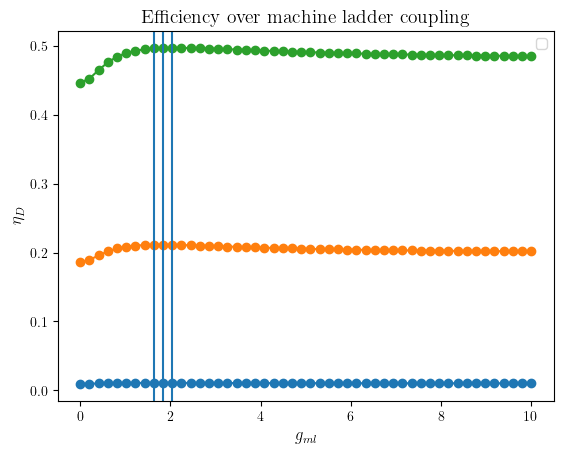

In [107]:
fig, ax = plt.subplots()
ax.set_xlabel("$g_{ml}$")
ax.set_ylabel("$\eta_D$")

[plt.plot(plot["g_ml"].values,plot["efficiency"].values,marker="o") for plot in plot_list]
plt.axvline(x=plot_list[0][plot_list[0]["efficiency"]==max(plot_list[0]["efficiency"])]["g_ml"].values[0])
plt.axvline(x=plot_list[1][plot_list[1]["efficiency"]==max(plot_list[1]["efficiency"])]["g_ml"].values[0])
plt.axvline(x=plot_list[2][plot_list[2]["efficiency"]==max(plot_list[2]["efficiency"])]["g_ml"].values[0])

# ax.set_yscale('log')
# ax.set_xscale('log')
# plt.xlim(0,20)
plt.title("Efficiency over machine ladder coupling")

# Add a caption
# caption = (r"\textbf{Figure 1.} parameters: "
#            fr"$R_M$={rateM}, $R_B$={rateB}, $R_D$={rateD}, $T_H$={TH}, $T_C$={TC}, $T_B$={Tb}, $T_D$={Td},"
#            r" \\ \quad"fr"$e_S$={e_s}, $e_C${e_C:.3f}, $e_l$={e_l}, "r"$g_{sl}$="fr"{g_sl}, "r"$g_{ml}$="fr"{g_ml}, $d_l$={d_l}, $t_f=${t_f}, "r"$t_\mathrm{steps}=$"fr"{t_steps}, $k=${k}")

# caption = (
#     r"\textbf{Figure 1.} Parameters: \\"
#     fr"$R_M={rateM}, R_B={rateB}, R_D={rateD},T_H={TH} T_C={TC}, T_B={Tb}, T_D={Td},$ \\"
#     r"\quad "
#     fr"$e_S={e_s}, e_C={e_C:.3f}, e_l={e_l}, g_{{sl}}={g_sl}, g_{{ml}}={g_ml}, d_l={d_l},$ \\"
#     fr"$t_f={t_f}, t_{{\mathrm{{steps}}}}={t_steps}, k={k}$"
# )

# plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)
plt.legend()

In [ ]:
plot_list_2=[]
parameters["TC"]=0.05
parameters["g_ml"]=1.8
for TV in [-0.2,-0.23,-0.28]:
    parameters["TV"]=TV
    plot_list_2.append(L_get_FoM_vari_one_parameter(parameters,"rateD",np.linspace(0.001,1,50)))

[[<matplotlib.lines.Line2D at 0x7d221d10b400>],

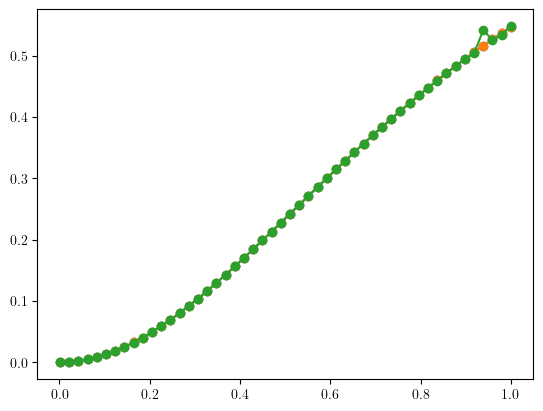

In [108]:
[plt.plot(plot["rateD"].values,plot["efficiency"].values,marker="o") for plot in plot_list_2]